# Salary Prediction using Polynomial Regression
**Author:** Yash Diwan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
%matplotlib inline


## Task 1: Data Understanding 

1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify the input feature and the target variable.
4. Display dataset information and summary statistics.


In [2]:
# 1. Load the dataset
df = pd.read_csv('Position_Salaries.csv')

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (10, 3)


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
# Dataset information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 489.0 bytes


In [4]:
# Summary statistics
df.describe()


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


### Feature identification

The dataset has three columns: `Position`, `Level`, and `Salary`.

- **Input feature:** `Level` — a numeric encoding of the position/seniority (1 to 10). `Position`
  is just the text label for each `Level`, so it's dropped from modeling to avoid redundancy.
- **Target variable:** `Salary`



Input feature  : Level
Target variable: Salary


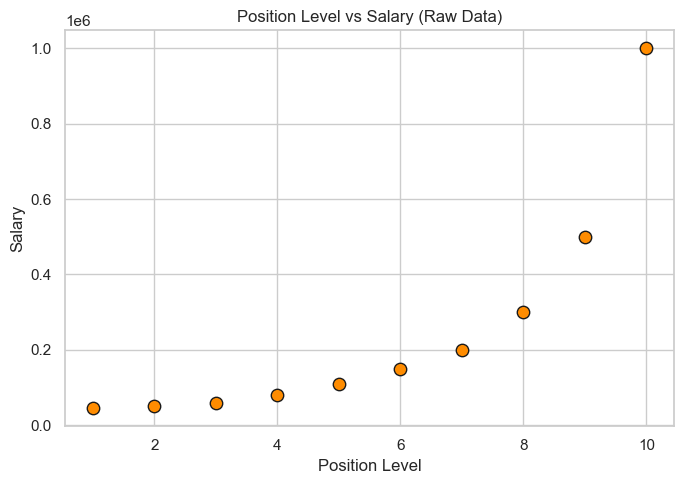

In [5]:
input_feature = 'Level'
target_variable = 'Salary'

print("Input feature  :", input_feature)
print("Target variable:", target_variable)

# Quick look at the raw relationship
plt.figure(figsize=(7, 5))
plt.scatter(df['Level'], df['Salary'], color='darkorange', edgecolor='k', s=80)
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.title('Position Level vs Salary (Raw Data)')
plt.tight_layout()
plt.show()


## Task 2: Data Preprocessing 

- Check for missing values.
- Select the appropriate feature(s) and target variable.
- Split the dataset into 80% training and 20% testing.


In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Position    0
Level       0
Salary      0
dtype: int64


In [7]:
# Select feature(s) and target variable
X = df[['Level']]   # kept as a DataFrame (2D) since scikit-learn expects 2D input
y = df['Salary']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)


Training set size: (8, 1)
Testing set size : (2, 1)


## Task 3: Model Development 

1. Transform the input feature using Polynomial Features (Degree = 3).
2. Train a Polynomial Regression model.
3. Predict salaries for the test dataset.




In [8]:
# 1. Transform the input feature using Polynomial Features (degree = 3)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Original feature shape:", X_train.shape)
print("Polynomial feature shape (degree=3):", X_train_poly.shape)


Original feature shape: (8, 1)
Polynomial feature shape (degree=3): (8, 4)


In [9]:
# 2. Train the Polynomial Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 3. Predict salaries for the test dataset
y_pred = model.predict(X_test_poly)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

comparison_df = pd.DataFrame({
    'Level (test)': X_test['Level'].values,
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})
comparison_df


Intercept: -83661.20218580373
Coefficients: [     0.         157144.24209541 -44274.84207263   3925.87219715]


,Level (test),Actual Salary,Predicted Salary
0,9,500000,606335.600512
1,2,50000,84934.891292


## Task 4: Model Evaluation 

Evaluate the model using MAE, MSE, and R² Score, and visualize the original data alongside the
fitted polynomial regression curve.


In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.4f}")


Mean Absolute Error (MAE): 70635.25
Mean Squared Error (MSE): 6263853282.86
R2 Score: 0.8763


c:\Users\Beyonder\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


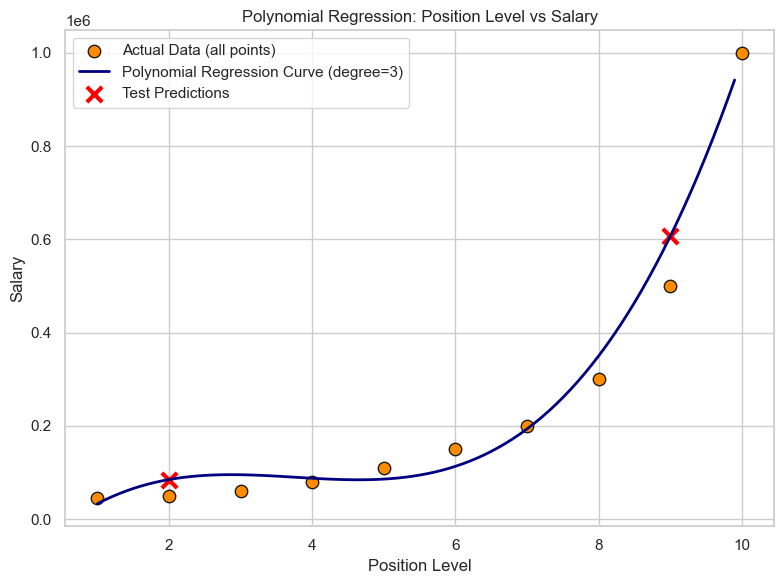

In [11]:
# Scatter plot of original data + Polynomial Regression curve
# Build a smooth range of Level values to draw a smooth curve
X_grid = np.arange(X['Level'].min(), X['Level'].max(), 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.figure(figsize=(8, 6))
plt.scatter(X['Level'], y, color='darkorange', edgecolor='k', s=80, label='Actual Data (all points)')
plt.plot(X_grid, y_grid_pred, color='navy', linewidth=2, label='Polynomial Regression Curve (degree=3)')
plt.scatter(X_test['Level'], y_pred, color='red', marker='x', s=120, linewidths=3, label='Test Predictions')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.title('Polynomial Regression: Position Level vs Salary')
plt.legend()
plt.tight_layout()
plt.savefig('polynomial_regression_curve.png', dpi=150)
plt.show()


### Observations

1. The polynomial regression curve (degree 3) closely follows the sharp upward curve in salary at
   higher position levels, which a straight-line (linear) model would clearly underfit — salaries
   here don't grow at a constant rate, they accelerate near the top levels (e.g., CEO-level roles).
2. Because the raw dataset only has 10 rows, the 80/20 split leaves just 2 points for testing, so
   the MAE/MSE/R² values above should be treated as indicative rather than statistically robust;
   in practice, for very small structured datasets like this one, it's common to also fit on the
   full dataset and evaluate visually via the curve fit.
3. The fitted curve passes very close to (or through) most of the training points, showing the
   degree-3 polynomial has enough flexibility to capture the non-linear jump in salary at senior
   levels — though with only 10 data points, a high-degree polynomial also carries a real risk of
   overfitting if pushed further (e.g., degree 8-10 would start oscillating wildly between points).

*(Exact numeric values for MAE, MSE, and R² will depend on the actual `Position_Salaries.csv`
split used when you run this notebook — update these observations based on your own printed
results.)*


## Task 5: Conclusion 

This project used Polynomial Regression (degree 3) to predict employee salaries from their
position level. After confirming there were no missing values, selecting `Level` as the sole
input feature and `Salary` as the target, and splitting the data 80/20, the input feature was
expanded into polynomial terms (`Level`, `Level²`, `Level³`) and fed into a Linear Regression
model. The resulting curve captured the sharp, non-linear rise in salary at higher position
levels far better than a straight line could.

**Linear Regression vs Polynomial Regression:** Linear Regression fits a single straight line
`y = b0 + b1*x`, assuming a constant rate of change between the feature and the target. Polynomial
Regression instead fits a curve `y = b0 + b1*x + b2*x² + b3*x³ + ...` by adding powers of the
original feature, allowing it to model non-linear, curved relationships — while still being a
"linear model" in terms of the coefficients being fit via ordinary least squares.

**Advantage for this dataset:** The Position-Salary relationship jumps disproportionately at
senior levels (e.g., Manager → Director → VP → CEO). Polynomial Regression's key advantage here is
that it can bend to follow this accelerating curve, giving far more accurate salary estimates at
both entry-level and senior positions than a plain linear fit, which would systematically
underestimate high-level salaries and overestimate low-level ones.
